In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
sys.path.append("/root/limlab01/kaistai/25DFT/QHFlow/src")
import md.scflow_calculator_gpu
from dft_process.dft_process_utils import *

gpu4pyscf is installed.


/root/miniforge3/envs/pyscf-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO     [dft_process_utils.py:32] >> Source path: /root/limlab01/kaistai/25DFT/QHFlow/src

INFO     [dft_process_utils.py:62] >> Root path: /root/limlab01/kaistai/25DFT/QHFlow

In [2]:
# md17_experiment = MD17Experiment(data_index=1)
# md17_experiment.set_model_path()

# cur_ckpt = "/root/25DFT/QHFlow/src/outputs/malondialdehyde/QHFlow_so2_v5_1_small_v2-malondialdehyde/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"
# cur_ckpt = "/root/25DFT/QHFlow/src/outputs/malondialdehyde/QHFlow_so2_v5_1_middle-malondialdehyde/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"
# cur_ckpt = "/root/25DFT/QHFlow/src/outputs/rmd-aspirin/QHFlow_so2_v5_1_middle-rmd-aspirin/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"
cur_ckpt = "/root/25DFT/QHFlow/src/outputs/ethanol/QHFlow_so2_v5_1_middle_b10-ethanol/checkpoints/weights-epoch=79-val_loss=0.0000000.ckpt"

INFO     [setup.py:66] >> Seed: 0

Seed set to 0


ConfigNamespace({'dataset_name': 'water', 'num_train': 500, 'num_valid': 500, 'density_loss': 0.01, 'max_radius': 15.0, 'batch_size': 16, 'train_batch_size': 16, 'valid_batch_size': 16, 'test_batch_size': 16})


INFO     [dft_process_utils.py:202] >> [!] conf.dataset.dataset_name: ethanol

md17
ethanol
MD17_DFT(30000)


In [7]:
sample_ethanol = [
    (6,  [-0.28630036, -0.47787276,  0.03603168]),  # C
    (6,  [-0.92012881,  0.96245698,  0.23729976]),  # C
    (8,  [ 1.10116376, -0.40535771, -0.20377836]),  # O
    (1,  [-0.49412140, -1.15617614,  0.94202625]),  # H
    (1,  [-0.80417700, -0.91072034, -0.80315132]),  # H
    (1,  [-1.91334152,  0.70271240,  0.63912332]),  # H
    (1,  [-0.36050056,  1.60555901,  0.92692388]),  # H
    (1,  [-0.93001164,  1.37368891, -0.73671183]),  # H
    (1,  [ 1.39790227, -0.95652028, -0.99060288]),  # H
]
sample_ethanol_atoms = [a[0] for a in sample_ethanol]
sample_ethanol_coords = [a[1] for a in sample_ethanol]
sample_ethanol_atoms, sample_ethanol_coords

([6, 6, 8, 1, 1, 1, 1, 1, 1],
 [[-0.28630036, -0.47787276, 0.03603168],
  [-0.92012881, 0.96245698, 0.23729976],
  [1.10116376, -0.40535771, -0.20377836],
  [-0.4941214, -1.15617614, 0.94202625],
  [-0.804177, -0.91072034, -0.80315132],
  [-1.91334152, 0.7027124, 0.63912332],
  [-0.36050056, 1.60555901, 0.92692388],
  [-0.93001164, 1.37368891, -0.73671183],
  [1.39790227, -0.95652028, -0.99060288]])

In [8]:
sccalculator = md.scflow_calculator_gpu.SCFlowRKSCalculator()

In [17]:
sccalculator.set_model(
    cur_ckpt,
    units="ang",
    model_length_unit="bohr",
    mf_init_functional="pbe,pbe",
    init_density_fit=False,
    init_gpu4pyscf=False,
    )

INFO     [__init__.py:104] >> model_args: {'in_node_features': 1, 'sh_lmax': 4, 'hidden_size': 128,                
         'bottle_hidden_size': 32, 'num_gnn_layers': 3, 'max_radius': 15, 'num_nodes': 10, 'radius_embed_dim': 16, 
         'max_T': 15, 'use_block_S': False, 'use_block_H': False, 'ham_dim': 24, 'ham_hidden': 288, 'dataset_type':
         'qh9', 'num_ham_gnn_layers': 2}

Setting device to cuda


INFO     [base_module.py:131] >> use_init_hamiltonian: False

INFO     [base_module.py:132] >> use_init_hamiltonian_residue: True

INFO     [base_module.py:133] >> ema_start_epoch: -1

INFO     [base_module.py:134] >> qh9: False

INFO     [base_module.py:135] >> test_mode: test

INFO     [flow_module.py:211] >> init_p0_type: expand

model trained on dataset:  ethanol
ode_steps: 1
max_radius: 1000
max_num_neighbors: 200


In [10]:
sample = md17_experiment.dataset[1]
sample.energy

tensor([-154.7023])

In [11]:
ase_atoms = md.scflow_calculator_gpu.QHData_to_atoms(sample, unit="bohr")

In [12]:
ase_atoms

Atoms(symbols='C2OH6', pbc=False, cell=[1.0, 1.0, 1.0])

In [18]:
properties = ["energy", "forces"]
system_changes = ["positions"]
sccalculator.calculate(ase_atoms, properties, system_changes, units="ang", model_length_unit="bohr")

{'energy': np.float64(-4209.667328367623),
 'forces': array([[ 2.69142452, -0.26335568,  0.71460994],
        [-2.56699443,  0.55612721,  1.28781141],
        [-1.40893785,  1.83795877,  1.68052746],
        [ 0.24967399,  0.53999608, -1.46015656],
        [-0.19609492, -0.98030684,  0.29746836],
        [ 0.60451502, -0.58826856, -1.00250402],
        [ 0.69425431, -0.28101342, -0.11054803],
        [ 0.0450263 , -0.126329  , -0.03927034],
        [-0.11154023, -0.69365752, -1.36793726]])}

In [19]:
sccalculator.ovlp.shape

(72, 72)

In [20]:
rkscalculator = md.scflow_calculator_gpu.RKSCalculator()
rkscalculator.calculate(ase_atoms, properties, system_changes, units="ang")
rkscalculator.results["energy"], rkscalculator.results["forces"]


(np.float64(-4209.667330380161),
 array([[ 2.6909368 , -0.26386579,  0.71404881],
        [-2.56532342,  0.55657352,  1.28805412],
        [-1.40993067,  1.83821185,  1.68041392],
        [ 0.24963645,  0.53999014, -1.45996905],
        [-0.19617558, -0.98056726,  0.29706653],
        [ 0.60435602, -0.58818898, -1.00262014],
        [ 0.6943716 , -0.28131752, -0.11031845],
        [ 0.04497239, -0.12599481, -0.03879684],
        [-0.11151693, -0.69369037, -1.36787787]]))

In [21]:
rkscalculator = md.scflow_calculator_gpu.UKSCalculator()
rkscalculator.calculate(ase_atoms, properties, system_changes, units="ang")
rkscalculator.results["energy"], rkscalculator.results["forces"]


(np.float64(-4209.667330382822),
 array([[ 2.6909593 , -0.26387315,  0.71404637],
        [-2.56532269,  0.55655917,  1.28803   ],
        [-1.40993804,  1.83821423,  1.68040838],
        [ 0.24963517,  0.53999076, -1.45996749],
        [-0.19617489, -0.98055959,  0.29707541],
        [ 0.60434521, -0.58818953, -1.00260564],
        [ 0.69436868, -0.28131637, -0.11032061],
        [ 0.04496984, -0.12598681, -0.03879267],
        [-0.11151592, -0.69368793, -1.36787272]]))

Output directory: /root/25DFT/QHFlow/src/md/test_script/outputs_ethanol_OH_20260107_004442
Data directory: /root/25DFT/QHFlow/src/md/test_script/outputs_ethanol_OH_20260107_004442/data
Plots directory: /root/25DFT/QHFlow/src/md/test_script/outputs_ethanol_OH_20260107_004442/plots
Using O index 2, H index 8, initial d=1.005 Å


INFO     [__init__.py:104] >> model_args: {'in_node_features': 1, 'sh_lmax': 4, 'hidden_size': 128,                
         'bottle_hidden_size': 32, 'num_gnn_layers': 3, 'max_radius': 15, 'num_nodes': 10, 'radius_embed_dim': 16, 
         'max_T': 15, 'use_block_S': False, 'use_block_H': False, 'ham_dim': 24, 'ham_hidden': 288, 'dataset_type':
         'qh9', 'num_ham_gnn_layers': 2}

Setting device to cuda


INFO     [base_module.py:131] >> use_init_hamiltonian: False

INFO     [base_module.py:132] >> use_init_hamiltonian_residue: True

INFO     [base_module.py:133] >> ema_start_epoch: -1

INFO     [base_module.py:134] >> qh9: False

INFO     [base_module.py:135] >> test_mode: test

INFO     [flow_module.py:211] >> init_p0_type: expand

model trained on dataset:  ethanol
ode_steps: 1
max_radius: 1000
max_num_neighbors: 200
Running model: scflow
0 0.01 6699.781176973002
0
1 0.1109090909090909 -3588.665885806277
0
2 0.21181818181818182 -3983.412869562179
0
3 0.31272727272727274 -4106.844365160774
0
4 0.41363636363636364 -4159.956198188921
0
5 0.5145454545454545 -4185.537107153757
0
6 0.6154545454545455 -4198.835128197555
0
7 0.7163636363636363 -4205.5513379048025
0
8 0.8172727272727273 -4208.574557108299
0
9 0.9181818181818182 -4209.817173179523
0
10 1.019090909090909 -4209.840333466159
0
11 1.1199999999999999 -4209.498867215702
0
12 1.220909090909091 -4208.972449165117
0
13 1.3218181818181818 -4208.213875378785
0
14 1.4227272727272726 -4207.754418537515
0
15 1.5236363636363637 -4207.277819446868
0
16 1.6245454545454545 -4206.765226679296
0
17 1.7254545454545454 -4205.70970941073
0
18 1.8263636363636364 -4205.147962430111
0
19 1.9272727272727272 -4204.670445929966
0
20 2.028181818181818 -4204.223127855145
0
21 2.1290909

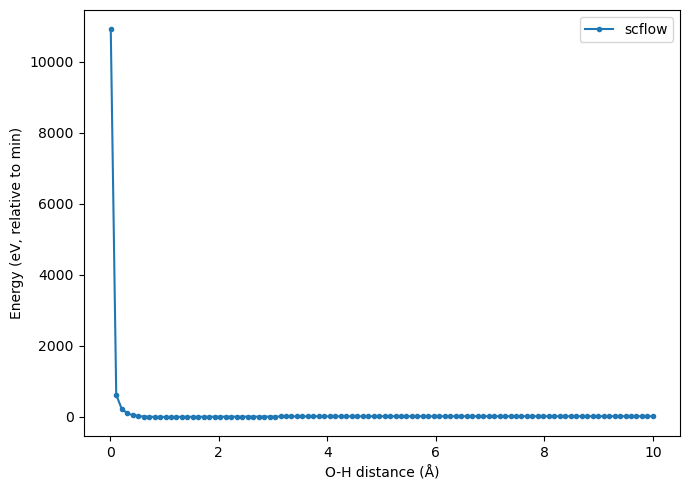

Saved combined plot to /root/25DFT/QHFlow/src/md/test_script/outputs_ethanol_OH_20260107_004442/plots/ethanol_dissociation_curves_d2_all.png


In [23]:
#!/usr/bin/env python
"""
Compute O–H bond dissociation curves for ethanol using trained models (eSEN, DimeNet, SchNet)
and optionally DFT (psi4). Outputs energies (relative to each curve minimum) and a plot.

This version is adapted for Jupyter notebook:
- No argparse / __main__
- You set input paths and options as variables below.
"""
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import torch
import time

# -----------------------------
# User configuration (edit here)
# -----------------------------
# Path to RMD17 ethanol HDF5 file
h5_path = Path("/home/yoonho/rmd_ham_data/rmd-ethanol/data.h5")

# Output directory for .npy and plots (with timestamp)
base_output_dir = Path("/root/25DFT/QHFlow/src/md/test_script")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = base_output_dir / f"outputs_ethanol_OH_{timestamp}"
data_dir = out_dir / "data"
plots_dir = out_dir / "plots"

# Distance range (Å) and number of points
dist_min = 0.01
dist_max = 10.0
# dist_max = 5.3
n_points = 100

# Models to use
# models = ["scflow", "dft2"]  # subset: e.g. ["esen"]
models = ["scflow"]  # subset: e.g. ["esen"]

mf_dict = {}
# Whether to compute DFT with psi4
compute_dft = False  # True / False

# Per-model GPU mapping, e.g. {"esen": "4", "dimenet": "5", "schnet": "6"}
gpu_map = None  # or dict, e.g. {"esen": "4", "dimenet": "5", "schnet": "6"}

# Plot prefix
plot_prefix = "ethanol_dissociation_curves_d2"
# -----------------------------


# Ensure local imports work (adapted to your project layout)
# NOTE: In a notebook, __file__ is not defined; use project root directly.
ROOT = Path("/root/25DFT/QHFlow/src").resolve()
sys.path.insert(0, str(ROOT))

# from mdsim.md.ase_utils import OCPCalculator, ESENCalculator  # type: ignore
from ase import Atoms


def load_base_atoms(h5_path: Path) -> Atoms:
    """Load atomic_numbers and positions from sample_0 of RMD17 HDF5."""
    with h5py.File(h5_path, "r") as f:
        idx = 0
        grp = f[f"sample_{idx}"]
        Z = grp["atomic_numbers"][:].astype(int)
        pos = grp["positions"][:]
    atoms = Atoms(numbers=Z, positions=pos)
    return atoms


def find_oh_pair(atoms: Atoms):
    """Return indices (iO, iH) where O is atomic number 8 and H is closest hydrogen to that O."""
    O_indices = [i for i, z in enumerate(atoms.get_atomic_numbers()) if z == 8]
    H_indices = [i for i, z in enumerate(atoms.get_atomic_numbers()) if z == 1]
    assert O_indices and H_indices, "No O/H atoms found"
    iO = O_indices[0]
    distances = [atoms.get_distance(iO, h) for h in H_indices]
    iH = H_indices[int(np.argmin(distances))]
    return iO, iH


def set_oh_distance(atoms: Atoms, iO: int, iH: int, target: float):
    """Move H along the O->H vector to achieve target distance (Å)."""
    atoms = atoms.copy()
    vec = atoms.positions[iH] - atoms.positions[iO]
    curr = np.linalg.norm(vec)
    if curr < 1e-8:
        return atoms
    delta = (vec / curr) * (target - curr)
    atoms.positions[iH] += delta
    return atoms


def run_curve_single(distances, calculator, atoms: Atoms, iO: int, iH: int):
    vals = []
    mf_list = []
    time_list = []
    for idx,d in enumerate(distances):
        start_time = time.time()
        geom = set_oh_distance(atoms, iO, iH, d)
        geom.calc = calculator
        vals.append(geom.get_potential_energy())
        print(idx, d, vals[-1])
        mf_list.append([d, geom.calc.mf])
        if hasattr(geom.calc.mf, "cycles"):
            print(geom.calc.mf.cycles)
        time_list.append(time.time() - start_time)
    return np.array(vals), mf_list, time_list

def shift_to_min(arr):
    return arr - np.nanmin(arr)


# ============================
# Main execution in notebook
# ============================

# Prepare output directories
out_dir.mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {out_dir}")
print(f"Data directory: {data_dir}")
print(f"Plots directory: {plots_dir}")

atoms = Atoms(numbers=sample_ethanol_atoms, positions=sample_ethanol_coords, cell=np.eye(3), pbc=False)
iO, iH = find_oh_pair(atoms)
print(f"Using O index {iO}, H index {iH}, initial d={atoms.get_distance(iO, iH):.3f} Å")

distances = np.linspace(dist_min, dist_max, n_points)

# Save original CUDA_VISIBLE_DEVICES
orig_cuda_env = os.environ.get("CUDA_VISIBLE_DEVICES", None)


def set_gpu(label):
    if gpu_map is None:
        # restore original if not using mapping
        if orig_cuda_env is None:
            os.environ.pop("CUDA_VISIBLE_DEVICES", None)
        else:
            os.environ["CUDA_VISIBLE_DEVICES"] = orig_cuda_env
        return

    dev = gpu_map.get(label, None)
    if dev is not None:
        os.environ["CUDA_VISIBLE_DEVICES"] = str(dev)
        try:
            torch.cuda.set_device(0)
        except Exception:
            pass
    else:
        # restore original if not using mapping
        if orig_cuda_env is None:
            os.environ.pop("CUDA_VISIBLE_DEVICES", None)
        else:
            os.environ["CUDA_VISIBLE_DEVICES"] = orig_cuda_env


energies = {}
time_dict = {}

# Build and run per-model sequentially on mapped GPU
for mdl in models:
    set_gpu(mdl)
    if mdl == "scflow":
        cur_ckpt = "/root/25DFT/QHFlow/src/outputs/ethanol/QHFlow_so2_v5_1_middle_b10-ethanol/checkpoints/weights-epoch=79-val_loss=0.0000000.ckpt"
        calc = md.scflow_calculator_gpu.SCFlowRKSCalculator()
        calc.set_model(
            cur_ckpt,
            units="ang",
            model_length_unit="bohr",
            mf_init_functional="pbe,pbe",
            init_density_fit=False,
            init_gpu4pyscf=False,
            )
    elif "uks-dft" in mdl:
        calc = md.scflow_calculator_gpu.UKSCalculator(max_cycle=200)
    elif "dft" in mdl:
        calc = md.scflow_calculator_gpu.RKSCalculator(max_cycle=200)
    else:
        print(f"Unknown model: {mdl}, skipping.")
        continue

    print(f"Running model: {mdl}")
    energy_list, mf_list, time_list= run_curve_single(distances, calc, atoms, iO, iH)
    energies[mdl] = energy_list
    mf_dict[mdl] = mf_list
    time_dict[mdl] = time_list
    del calc
    torch.cuda.empty_cache()

# restore original env
if orig_cuda_env is None:
    os.environ.pop("CUDA_VISIBLE_DEVICES", None)
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = orig_cuda_env

# Save raw energies per model and plots
for name, arr in energies.items():
    np.save(data_dir / f"ethanol_{name}_energies.npy", arr)
    plt.figure(figsize=(7, 5))
    rel = shift_to_min(arr)
    plt.plot(distances, rel, marker="o", ms=3, label=name)
    plt.xlabel("O-H distance (Å)")
    plt.ylabel("Energy (eV, relative to min)")
    plt.legend()
    plt.tight_layout()
    out_plot = plots_dir / f"{plot_prefix}_{name}.png"
    plt.savefig(out_plot, dpi=200)
    plt.close()
    print(f"Saved plot to {out_plot}")

    plt.figure(figsize=(7, 5))
    rel = shift_to_min(arr)
    plt.plot(distances[2:], rel[2:], marker="o", ms=3, label=name)
    plt.xlabel("O-H distance (Å)")
    plt.ylabel("Energy (eV, relative to min)")
    plt.legend()
    plt.tight_layout()
    out_plot = plots_dir / f"{plot_prefix}_{name}_exclude.png"
    plt.savefig(out_plot, dpi=200)
    plt.close()
    print(f"Saved plot to {out_plot}")

# Combined plot
plt.figure(figsize=(7, 5))
for name, arr in energies.items():
    rel = shift_to_min(arr)
    plt.plot(distances, rel, marker="o", ms=3, label=name)
plt.xlabel("O-H distance (Å)")
plt.ylabel("Energy (eV, relative to min)")
plt.legend()
plt.tight_layout()
combined = plots_dir / f"{plot_prefix}_all.png"
plt.savefig(combined, dpi=200)
plt.show()
print(f"Saved combined plot to {combined}")

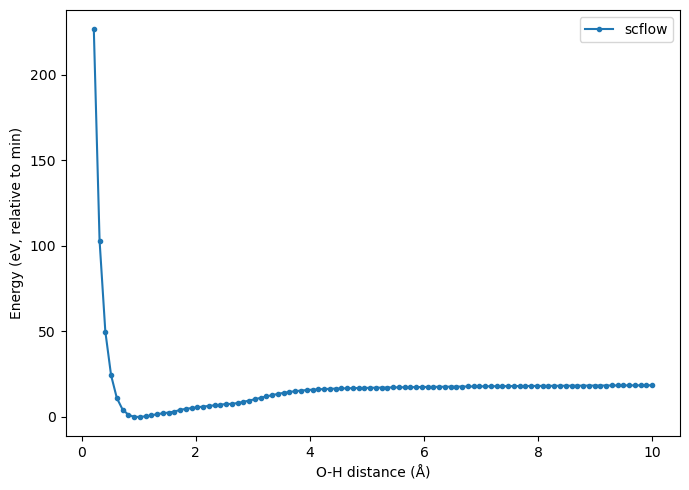

Saved combined plot to /root/25DFT/QHFlow/src/md/test_script/outputs_ethanol_OH_20260107_004442/plots/ethanol_dissociation_curves_d2_all_exclude.png


In [24]:
plt.figure(figsize=(7, 5))
for name, arr in energies.items():
    rel = shift_to_min(arr)
    plt.plot(distances[2:], rel[2:], marker="o", ms=3, label=name)
plt.xlabel("O-H distance (Å)")
plt.ylabel("Energy (eV, relative to min)")
plt.legend()
plt.tight_layout()
combined = plots_dir / f"{plot_prefix}_all_exclude.png"
plt.savefig(combined, dpi=200)
plt.show()
print(f"Saved combined plot to {combined}")

In [25]:
# Plot energy and max cycles for DFT models (dual y-axis)
for name in mf_dict.keys():
    if "dft" in name.lower():
        mf_list = mf_dict[name]
        cycles_distances = []
        cycles_values = []
        for d, mf in mf_list:
            if hasattr(mf, "cycles"):
                cycles_distances.append(d)
                cycles_values.append(mf.cycles)
        
        if cycles_values and name in energies:
            # Get energy values for the same distances
            energy_arr = energies[name]
            energy_distances = distances
            
            # Match distances for cycles and energies
            energy_matched = []
            cycles_matched = []
            dist_matched = []
            for i, d in enumerate(cycles_distances):
                # Find closest distance in energy_distances
                idx = np.argmin(np.abs(energy_distances - d))
                energy_matched.append(energy_arr[idx])
                cycles_matched.append(cycles_values[i])
                dist_matched.append(d)
            
            if energy_matched:
                fig, ax1 = plt.subplots(figsize=(7, 5))
                
                # Left y-axis: Energy
                rel_energy = shift_to_min(np.array(energy_matched))
                color1 = 'tab:blue'
                ax1.set_xlabel("O-H distance (Å)")
                ax1.set_ylabel("Energy (eV, relative to min)", color=color1)
                line1 = ax1.plot(dist_matched, rel_energy, marker="o", ms=3, 
                                label=f"{name} energy", color=color1)
                ax1.tick_params(axis='y', labelcolor=color1)
                ax1.grid(True, alpha=0.3)
                
                # Right y-axis: SCF cycles
                ax2 = ax1.twinx()
                color2 = 'tab:red'
                ax2.set_ylabel("SCF cycles", color=color2)
                line2 = ax2.plot(dist_matched, cycles_matched, marker="s", ms=3, 
                                 label=f"{name} cycles", color=color2, linestyle='--')
                ax2.tick_params(axis='y', labelcolor=color2)
                
                # Combine legends
                lines = line1 + line2
                labels = [l.get_label() for l in lines]
                ax1.legend(lines, labels, loc=7, frameon=False)
                
                plt.title(f"Energy and SCF Cycles vs O-H Distance ({name})")
                plt.tight_layout()
                cycles_plot = plots_dir / f"{plot_prefix}_{name}_energy_cycles.png"
                plt.savefig(cycles_plot, dpi=200)
                plt.show()
                print(f"Saved energy and cycles plot to {cycles_plot}")
                
                # Save original data as npy files
                np.save(data_dir / f"{plot_prefix}_{name}_distances.npy", np.array(dist_matched))
                np.save(data_dir / f"{plot_prefix}_{name}_energies_matched.npy", np.array(energy_matched))
                np.save(data_dir / f"{plot_prefix}_{name}_cycles.npy", np.array(cycles_matched))
                print(f"Saved data files:")
                print(f"  - {data_dir / f'{plot_prefix}_{name}_distances.npy'}")
                print(f"  - {data_dir / f'{plot_prefix}_{name}_energies_matched.npy'}")
                print(f"  - {data_dir / f'{plot_prefix}_{name}_cycles.npy'}")

In [26]:
# Plot energy and max cycles for DFT models (dual y-axis)
for name in mf_dict.keys():
    if "dft" in name.lower():
        mf_list = mf_dict[name]
        cycles_distances = []
        cycles_values = []
        for d, mf in mf_list:
            if hasattr(mf, "cycles"):
                cycles_distances.append(d)
                cycles_values.append(mf.cycles)
        
        if cycles_values and name in energies:
            # Get energy values for the same distances
            energy_arr = energies[name]
            energy_distances = distances
            
            # Match distances for cycles and energies
            energy_matched = []
            cycles_matched = []
            dist_matched = []
            for i, d in enumerate(cycles_distances):
                # Find closest distance in energy_distances
                idx = np.argmin(np.abs(energy_distances - d))
                energy_matched.append(energy_arr[idx])
                cycles_matched.append(cycles_values[i])
                dist_matched.append(d)
            
            if energy_matched:
                fig, ax1 = plt.subplots(figsize=(7, 5))
                
                # Left y-axis: Energy
                rel_energy = shift_to_min(np.array(energy_matched))
                color1 = 'tab:blue'
                ax1.set_xlabel("O-H distance (Å)")
                ax1.set_ylabel("Energy (eV, relative to min)", color=color1)
                line1 = ax1.plot(dist_matched[2:], rel_energy[2:], marker="o", ms=3, 
                                label=f"{name} energy", color=color1)
                ax1.tick_params(axis='y', labelcolor=color1)
                ax1.grid(True, alpha=0.3)
                
                # Right y-axis: SCF cycles
                ax2 = ax1.twinx()
                color2 = 'tab:red'
                ax2.set_ylabel("SCF cycles", color=color2)
                line2 = ax2.plot(dist_matched[2:], cycles_matched[2:], marker="s", ms=3, 
                                 label=f"{name} cycles", color=color2, linestyle='--')
                ax2.tick_params(axis='y', labelcolor=color2)
                
                # Combine legends
                lines = line1 + line2
                labels = [l.get_label() for l in lines]
                ax1.legend(lines, labels, loc=7, frameon=False)
                
                plt.title(f"Energy and SCF Cycles vs O-H Distance ({name})")
                plt.tight_layout()
                cycles_plot = plots_dir / f"{plot_prefix}_{name}_energy_cycles_exclude.png"
                plt.savefig(cycles_plot, dpi=200)
                plt.show()
                print(f"Saved energy and cycles plot to {cycles_plot}")